# Feature Explanation User Study

Compare no explanation, feature importance, and signed attribution with a KNN virtual participant. Training always precedes testing; `tested_w_xai` is randomized only within testing.

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'api.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.api import xaikitTest
from src.xai_adapter.api import (
    generate_ai_prediction_table,
    generate_xai_explanation_tables,
    init_explanation_run,
)

SEED = 42
BASELINE_MODEL = 'knn'  # knn, decision_tree, logistic_regression, or mlp
OUTPUT_DIR = Path(os.environ.get(
    'XAIKIT_TUTORIAL_OUTPUT_DIR',
    repo_root / 'tutorials' / 'feature_explanation_output',
))

## 1. Configure the study

`phase` is part of the required participant journey, not an IV. Every participant receives 10 training trials followed by 20 testing trials.

In [2]:
study = xaikitTest('feature_explanation_user_study', output_dir=OUTPUT_DIR)
study.add_iv('xai_type', 'between', ['none', 'importance', 'attribution'])
study.add_iv('tested_w_xai', 'within', [False, True], randomization='trial')
study.add_cv('user_task', ['forward_simulation'])
study.add_cv('num_attributes_shown', [5])
study.add_dv('forward_accuracy', ['continuous'])
study.validate_design()

study.set_study_protocol(
    study_title='Learning from feature explanations',
    research_questions=[
        'Does explanation type change forward-simulation accuracy?',
        'Does explanation visibility during testing change accuracy?',
    ],
    study_summary='Participants learn from one display, then predict AI outputs during testing.',
    consent_text='Replace with the approved consent and data-handling information.',
    start_survey_questions=['How familiar are you with AI systems?'],
    end_survey_questions=['How helpful was the display?'],
    procedure_steps=[
        {'title': 'Consent', 'kind': 'consent'},
        {'title': 'Background survey', 'kind': 'survey'},
        {'title': 'Training', 'kind': 'practice'},
        {'title': 'Testing', 'kind': 'trials'},
        {'title': 'End survey', 'kind': 'survey'},
        {'title': 'Debrief', 'kind': 'debrief'},
    ],
)


IV configuration:
  xai_type             type=between  randomization=-     levels=['none', 'importance', 'attribution']
  tested_w_xai         type=within   randomization=trial levels=[False, True]

CVs: ['user_task', 'num_attributes_shown']
DVs: ['forward_accuracy']


## 2. Train the AI, then sample balanced trials

Trial IDs depend on the trained AI. Each participant receives five predictions from each class during training and ten from each class during testing; class order is randomized inside each phase.

In [3]:
data = study.prepare_dataset(
    'wine_quality',
    feature_cols=['Alcohol', 'Sulphates', 'SO2', 'Vinegar Taint', 'pH'],
    rank_features_by_target=False,
    model_type='mlp',
    test_size=0.4,
    random_state=SEED,
)
study.train_AI_model(
    model_type='mlp',
    target_metric='accuracy',
    target_score=0.90,
    max_epochs=1000,
    check_every_epochs=10,
    batch_size=100,
    verbose=False,
)
trial_result = study.generate_trials(
    participants_per_between_condition=8,
    num_training=10,
    num_testing=20,
    balance_by_ai_prediction=True,
    output_dir='trials',
    seed=SEED,
    preview_rows=4,
)
trials = pd.DataFrame(trial_result.trials)
balance_audit = (
    trials.groupby(['participantId', 'phase', 'sampled_ai_prediction'])
    .size().rename('trials').reset_index()
    .groupby(['phase', 'sampled_ai_prediction'])['trials']
    .agg(['min', 'max']).reset_index()
)
display(study.training_summary_table(), balance_audit)

Available training datasets: ['adult', 'breast_cancer', 'cardiotocography', 'forest_cover', 'heart_disease', 'king_county_housing', 'mushrooms', 'prima_diabetes', 'wine_quality']
Dataset   : wine_quality  (1599 rows, 5 model features)
Features  : ['Alcohol', 'Sulphates', 'SO2', 'Vinegar Taint', 'pH']
Encoding  : one-hot
Train set : 959 samples  (60%)
Test set  : 640 samples  (40%)
Class balance (train) -> class 0: 829
Class balance (train) -> class 1: 130
First test instanceIds: [1188, 902, 818, 38, 1255, 496, 947, 861, 839, 1559]
Counterbalancing strategy: complete_counterbalancing
Participant assignments: 24 total
Instance pool rows: 300
Trial rows: 720
Exported trial artifacts:
  CSV     : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_output/trials/trials.csv
  JSON    : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_output/trials/trials.json
  Summary : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test

,target_metric,target_score,final_score,epochs,batch_size,reached_target,target_accuracy,final_accuracy,model_type,dataset
0,accuracy,0.9,0.903024,220,100,True,0.9,0.903024,mlp,wine_quality


,phase,sampled_ai_prediction,min,max
0,testing,0,10,10
1,testing,1,10,10
2,training,0,5,5
3,training,1,5,5


## 3. Generate the prediction and explanation pool

LIME supplies signed attribution values. The importance display uses their absolute values. Explanations are generated only for training trials and testing trials where XAI is visible; AI predictions remain available internally for scoring.

In [4]:
xai_visible = (
    ~trials['xai_type'].astype(str).str.lower().isin(['none', 'no_xai', 'control'])
    & (
        trials['phase'].eq('training')
        | trials['tested_w_xai'].fillna(False).astype(bool)
    )
)
explanation_ids = list(dict.fromkeys(
    trials.loc[xai_visible, 'instanceId'].astype(int).tolist()
))
explanation_config = init_explanation_run(
    data=data,
    iv_config={'xai_method': {'levels': ['lime']}},
    trained_ai_model=study.trained_ai_model,
    model_name=study.model_name,
    output_dir=OUTPUT_DIR / 'explanations',
    target=1,
    method_kwargs={'lime': {'num_samples': 1000}},
    instance_ids=explanation_ids,
    predictions_by_instance=study.ai_predictions_by_instance,
)
_, explanation_tables = generate_xai_explanation_tables(explanation_config)
prediction_path, prediction_df = generate_ai_prediction_table(explanation_config)

attribution_df = explanation_tables[0].copy()
attribution_df['expMethod'] = 'attribution'
importance_df = attribution_df.copy()
importance_df['expMethod'] = 'importance'
value_cols = [c for c in importance_df if c.startswith('a') and c.endswith('_i')]
importance_df[value_cols] = importance_df[value_cols].abs()

prediction_pool = pd.concat(
    [prediction_df, attribution_df, importance_df],
    ignore_index=True,
    sort=False,
)
study.prediction_table_path = prediction_path
study.prediction_table = prediction_df
study.combined_explanations = prediction_pool
display(prediction_pool['expMethod'].value_counts().rename('rows').to_frame())


Generating explanations for xai method: lime
  Sampled instances: 227


/var/folders/96/n6tgn0rs16bfp1cm36gy56hh0000gn/T/ipykernel_9463/1061759279.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  | trials['tested_w_xai'].fillna(False).astype(bool)


  Saved: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_output/explanations/lime_mlp_wine_quality.csv shape=(227, 12)

Saved complete AI prediction table: /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_output/explanations/predictions_mlp_wine_quality.csv shape=(1599, 5)


,rows
expMethod,
__prediction_only__,1599
attribution,227
importance,227


## 4. Configure and preview the KNN participant

Training previews show AI feedback. Testing previews automatically hide the AI prediction and its box, whether or not the explanation is visible.

ipywidgets unavailable. Showing HTML Back/Next preview.


participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction
3,1,training,235,attribution,False,0
participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction
3,2,training,1090,attribution,False,1
participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction
3,3,training,2,attribution,False,0
participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction
3,4,training,154,attribution,False,0
participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction
3,5,training,1544,attribution,False,1
participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction

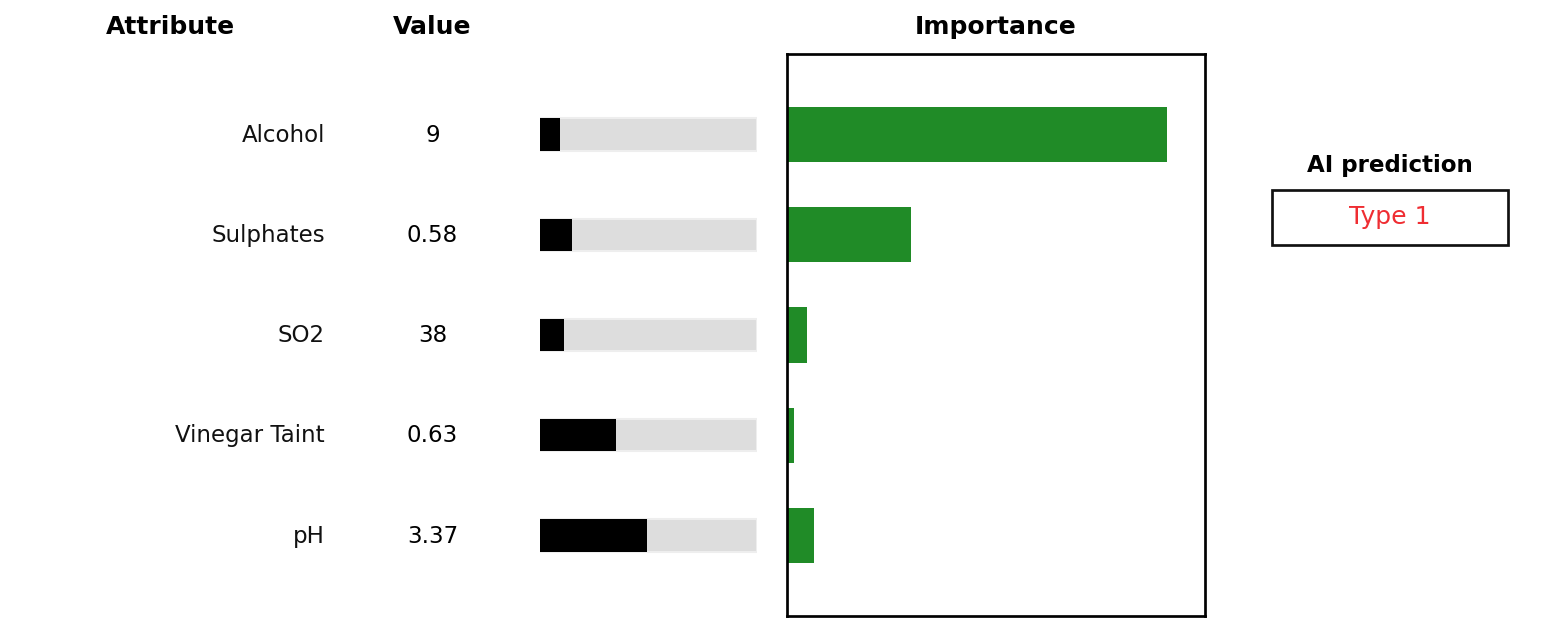
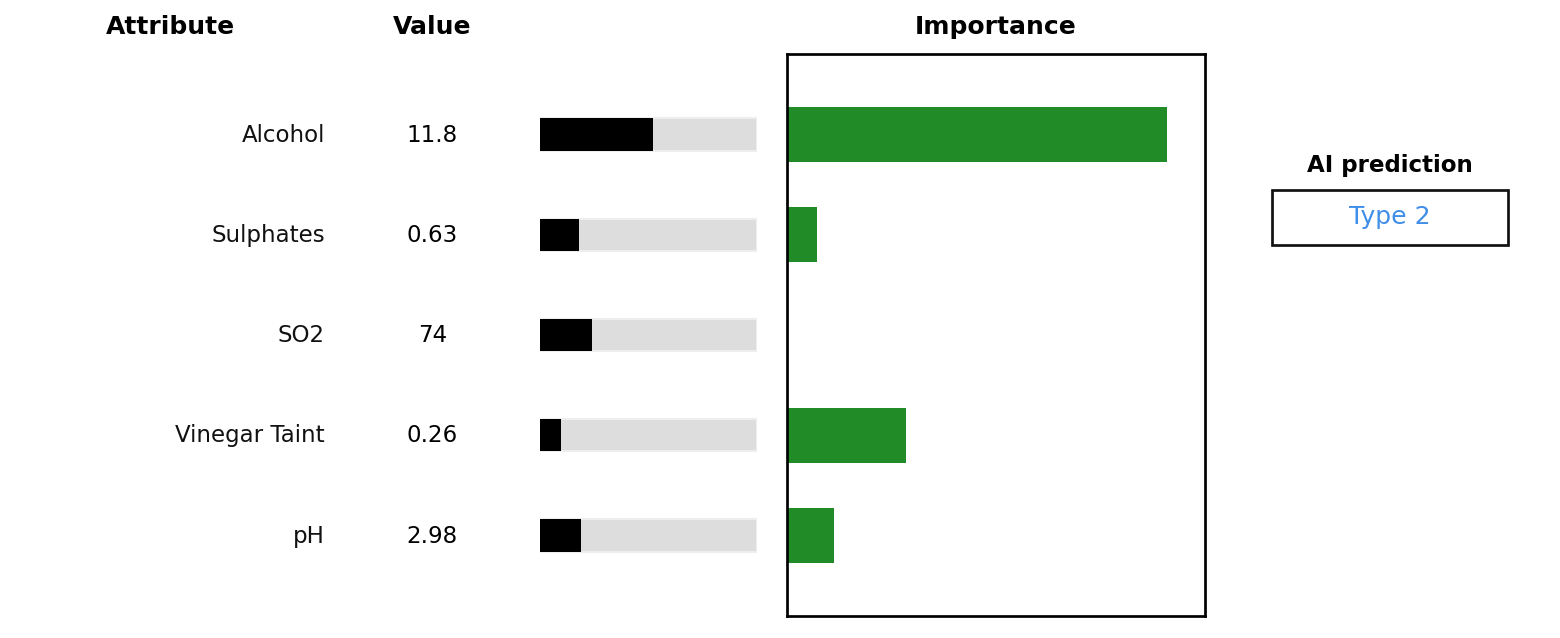
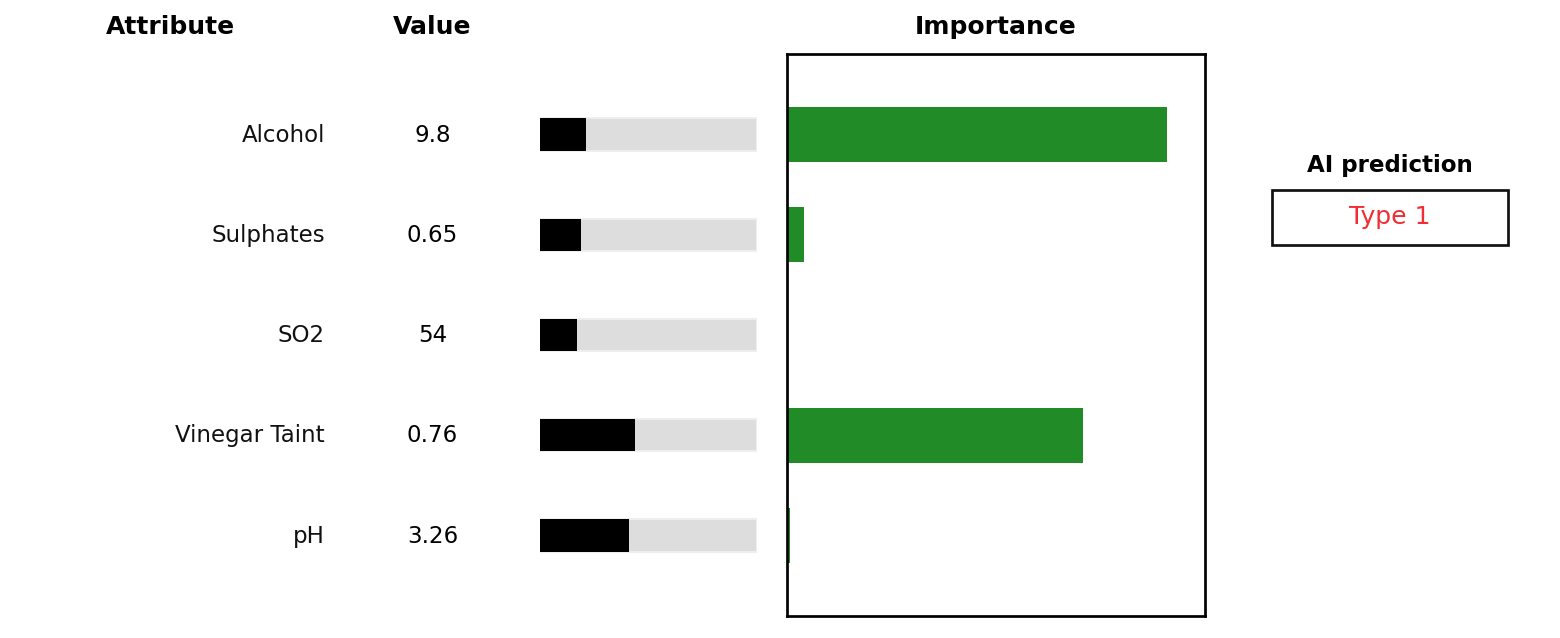
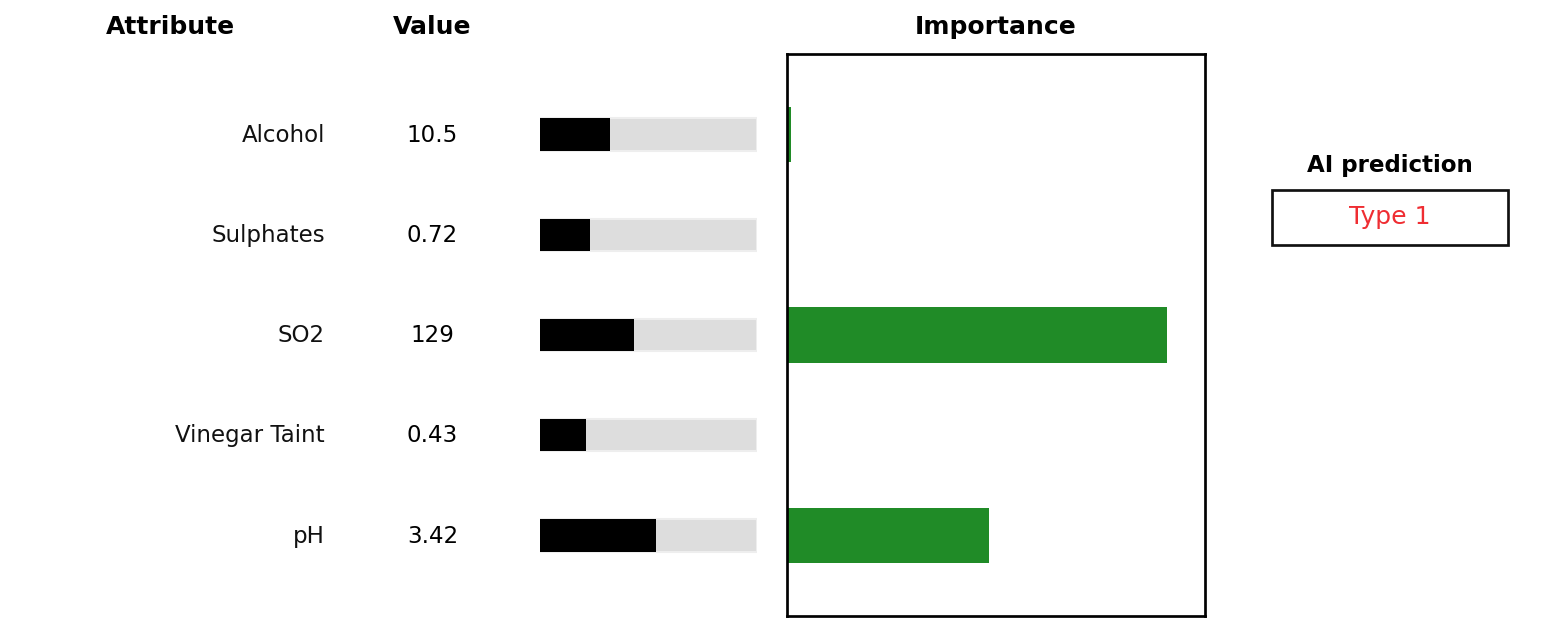
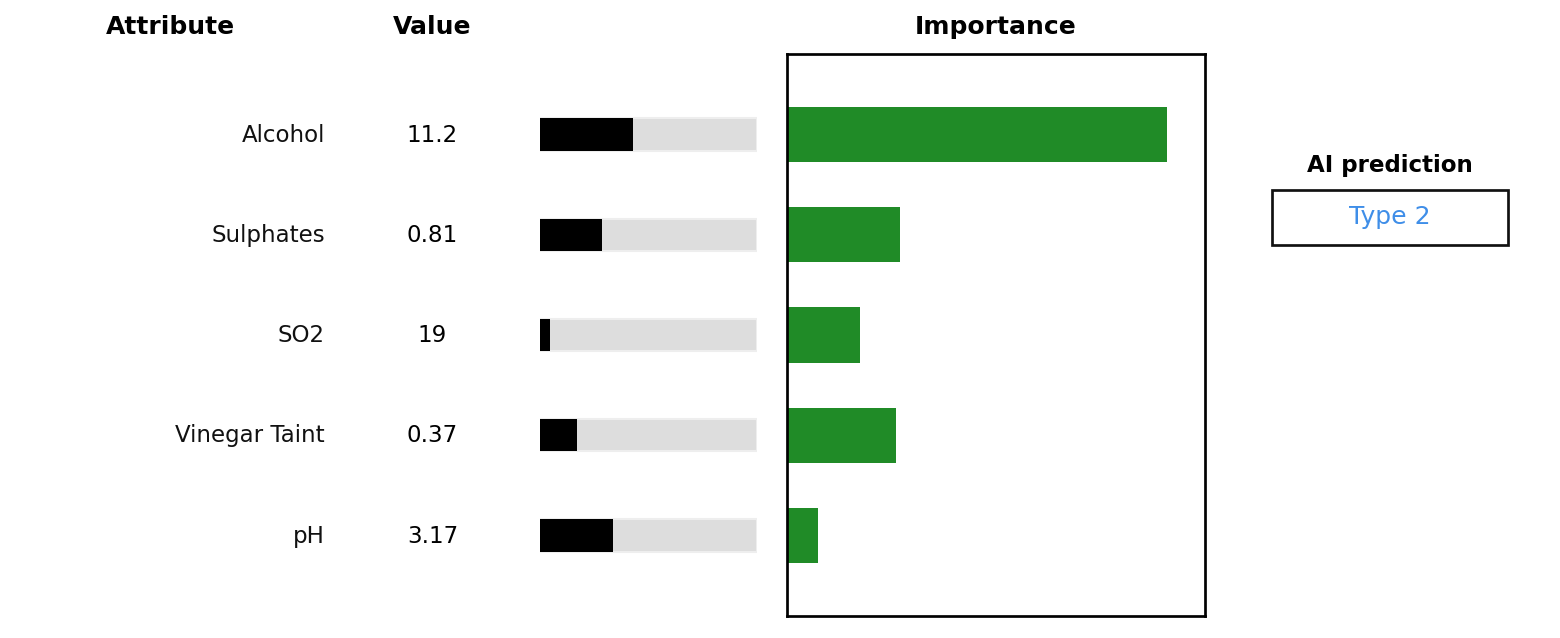
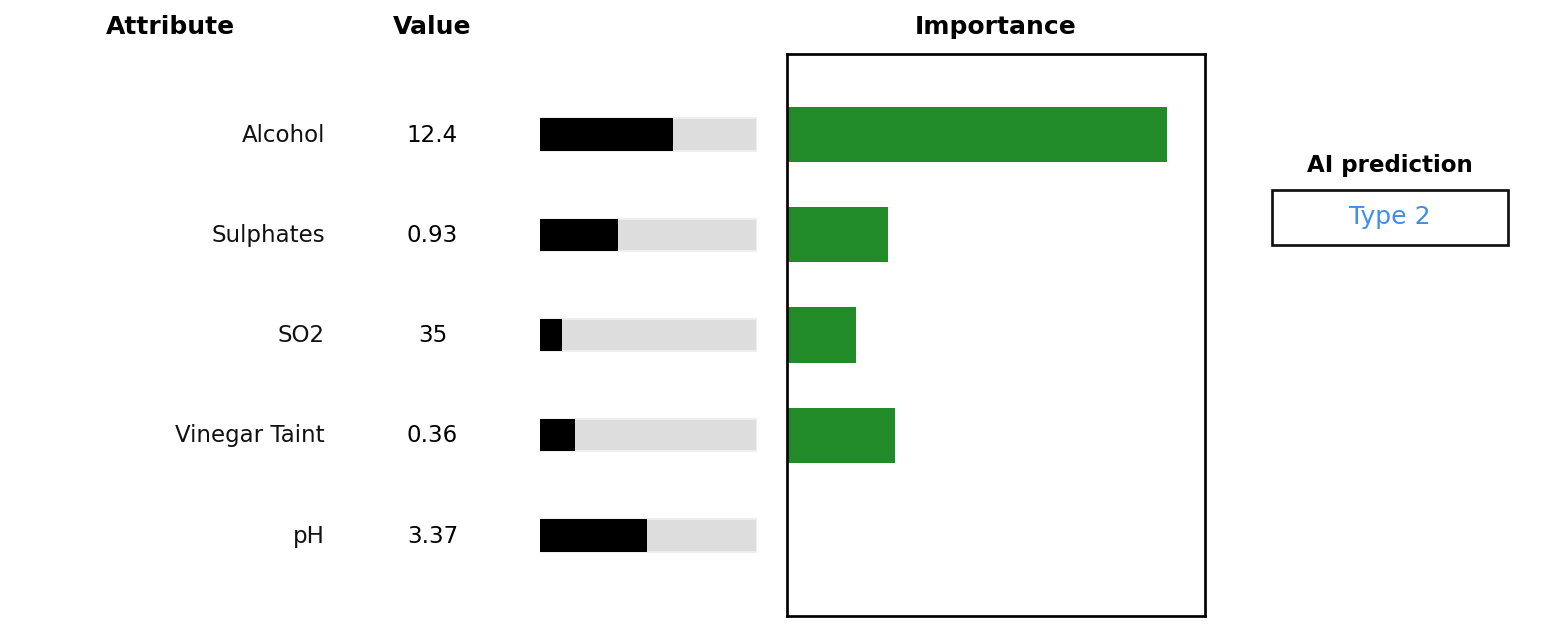
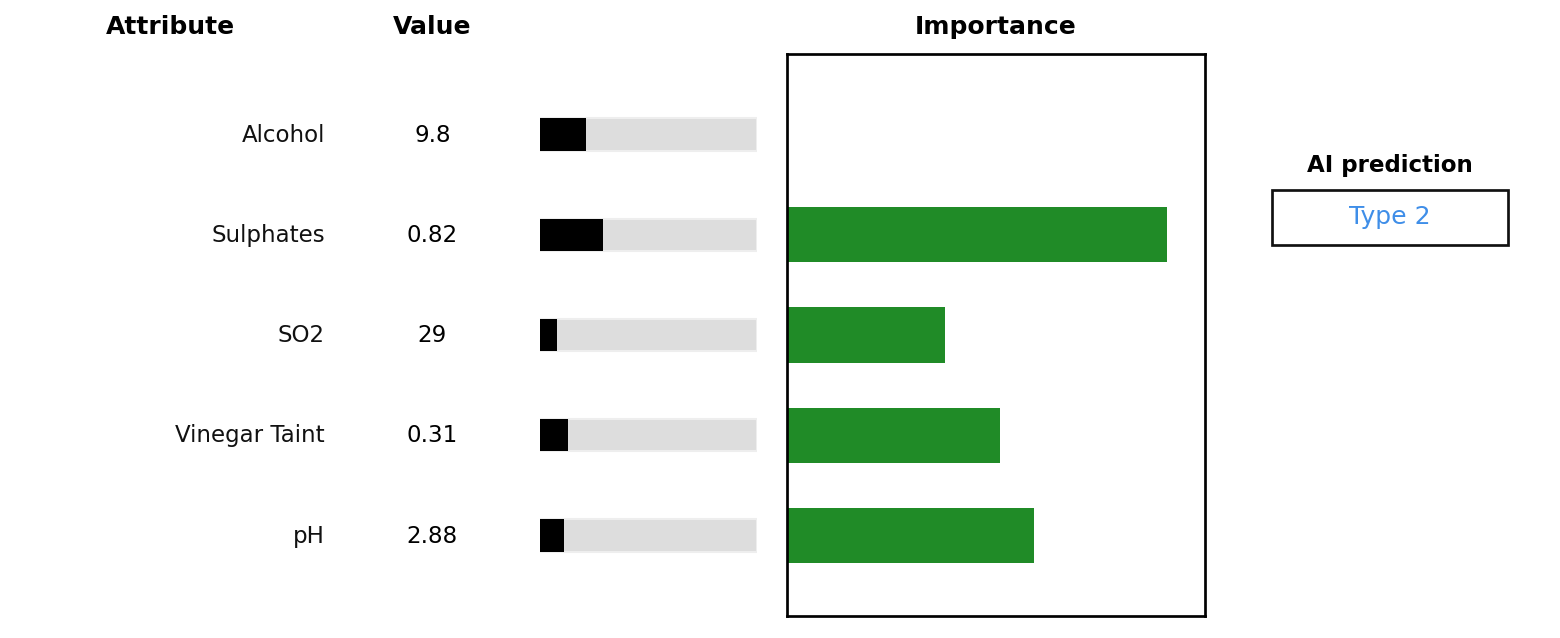
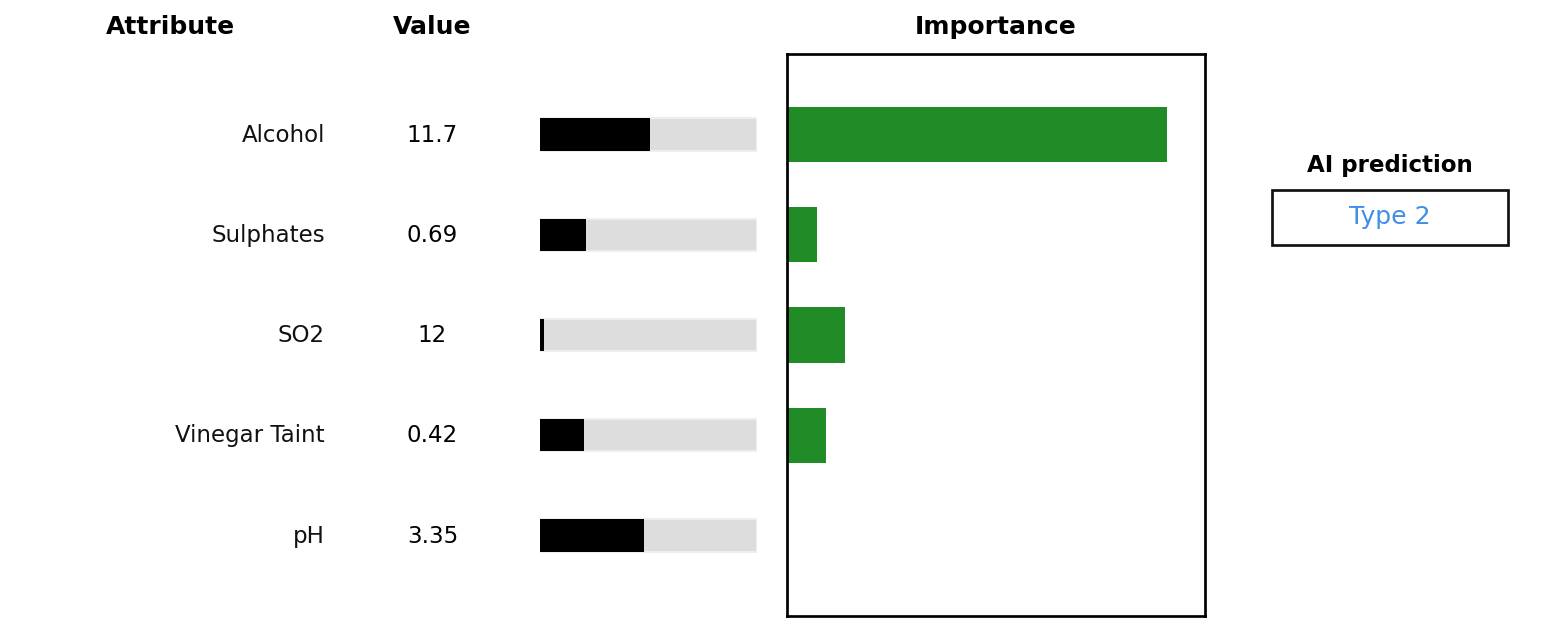
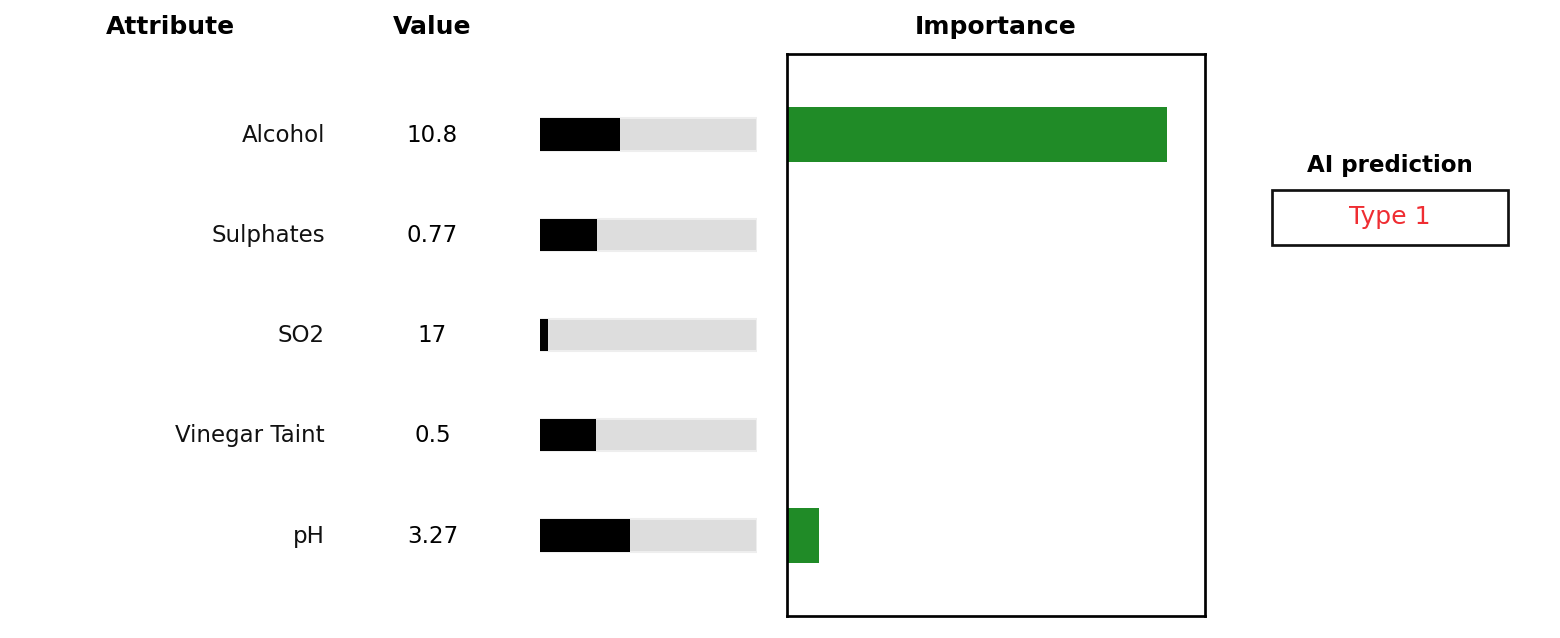
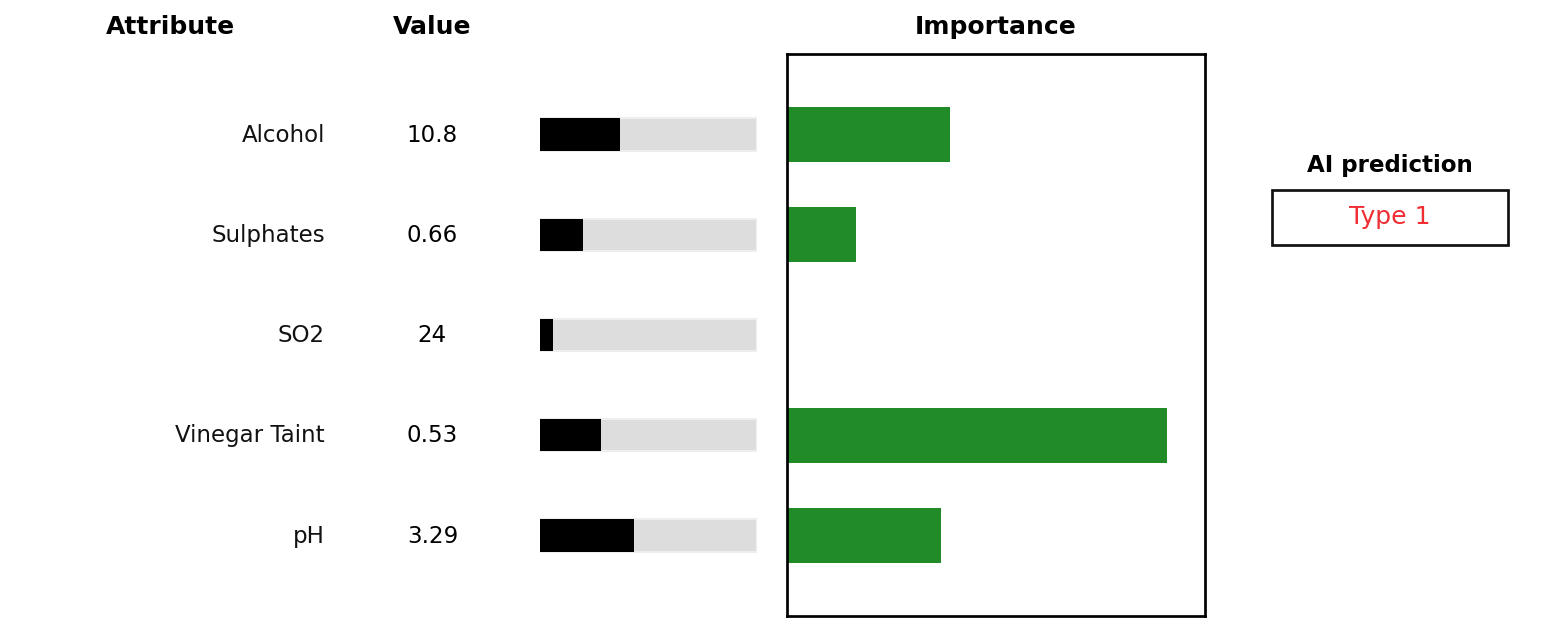
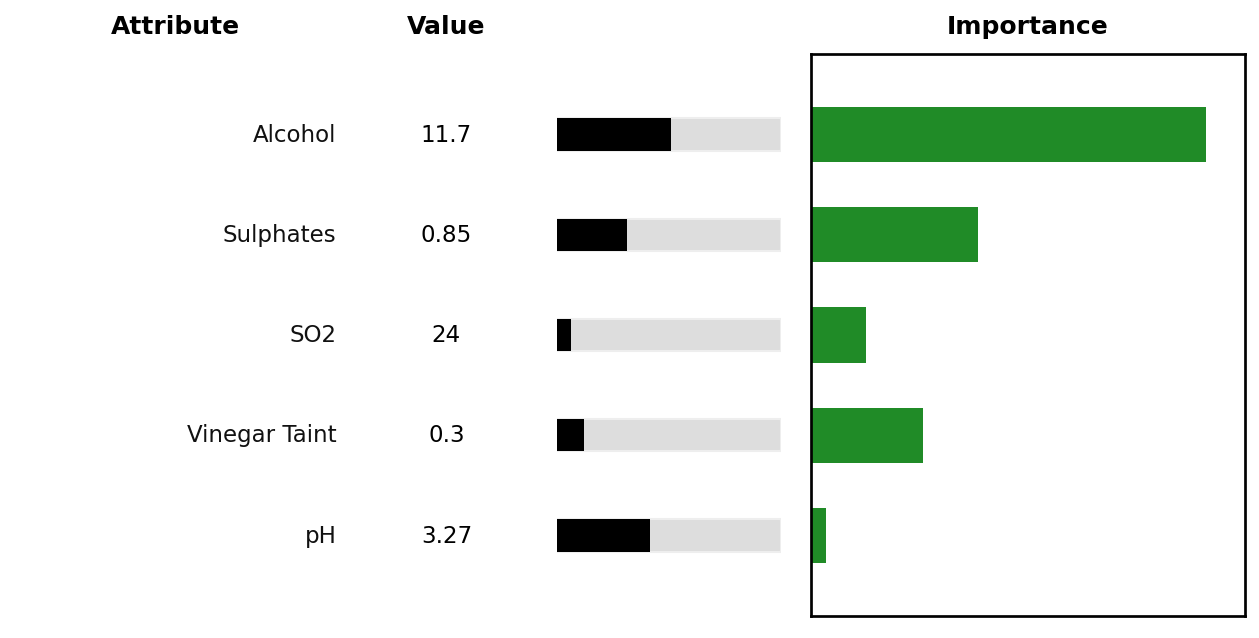
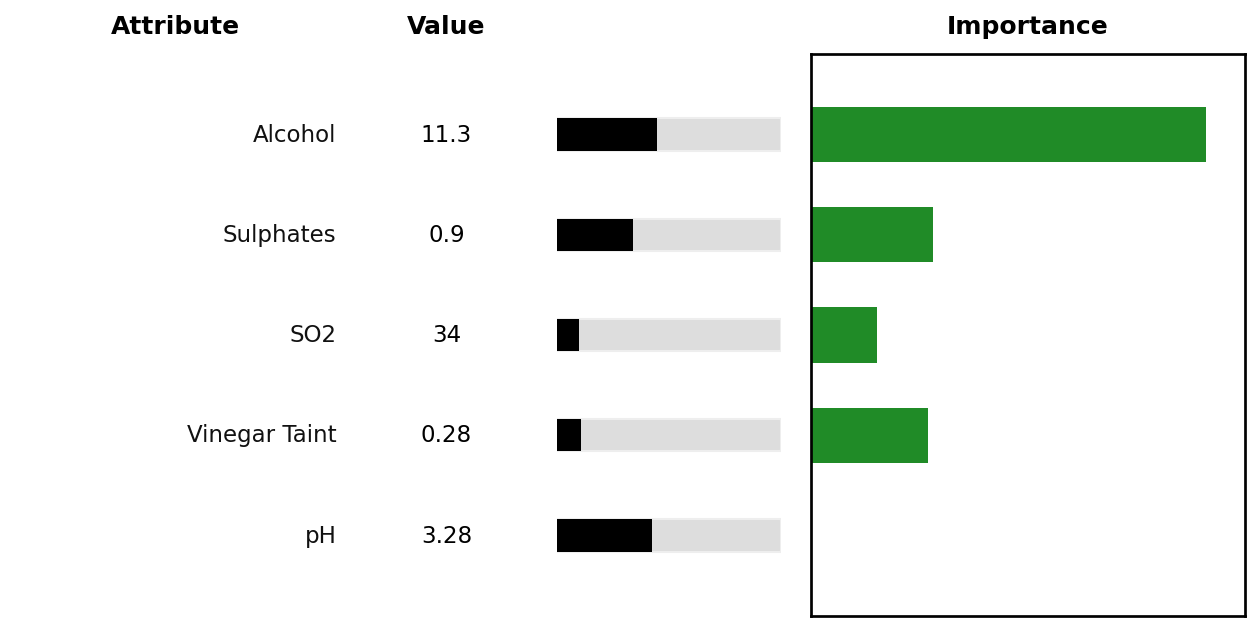
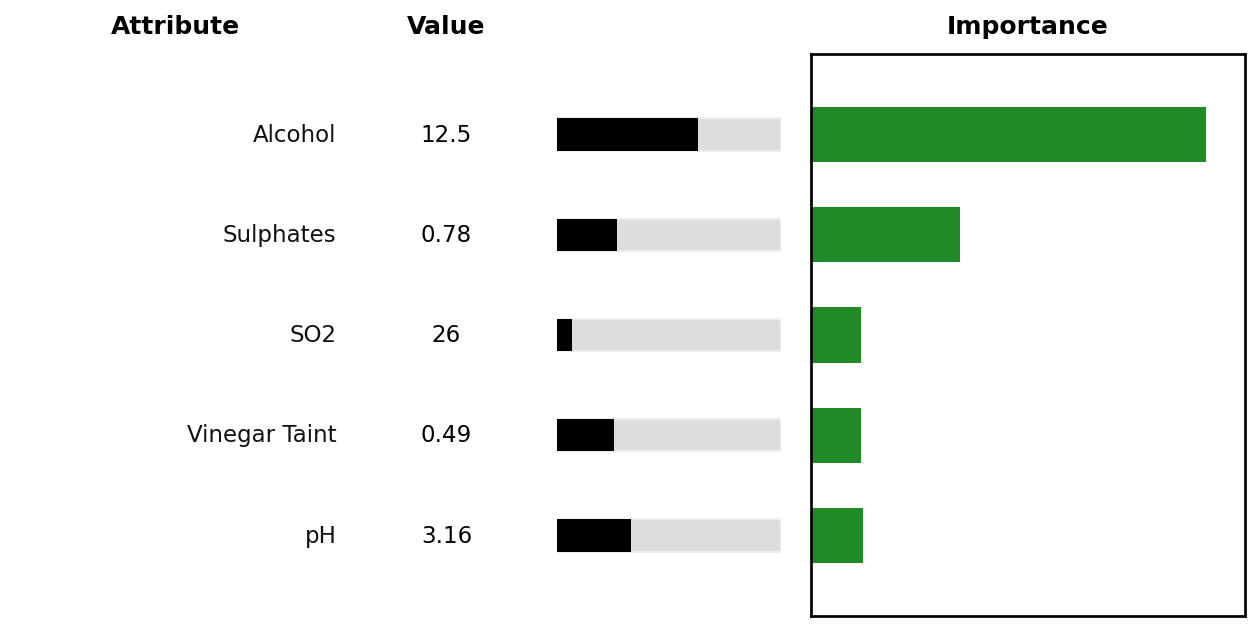
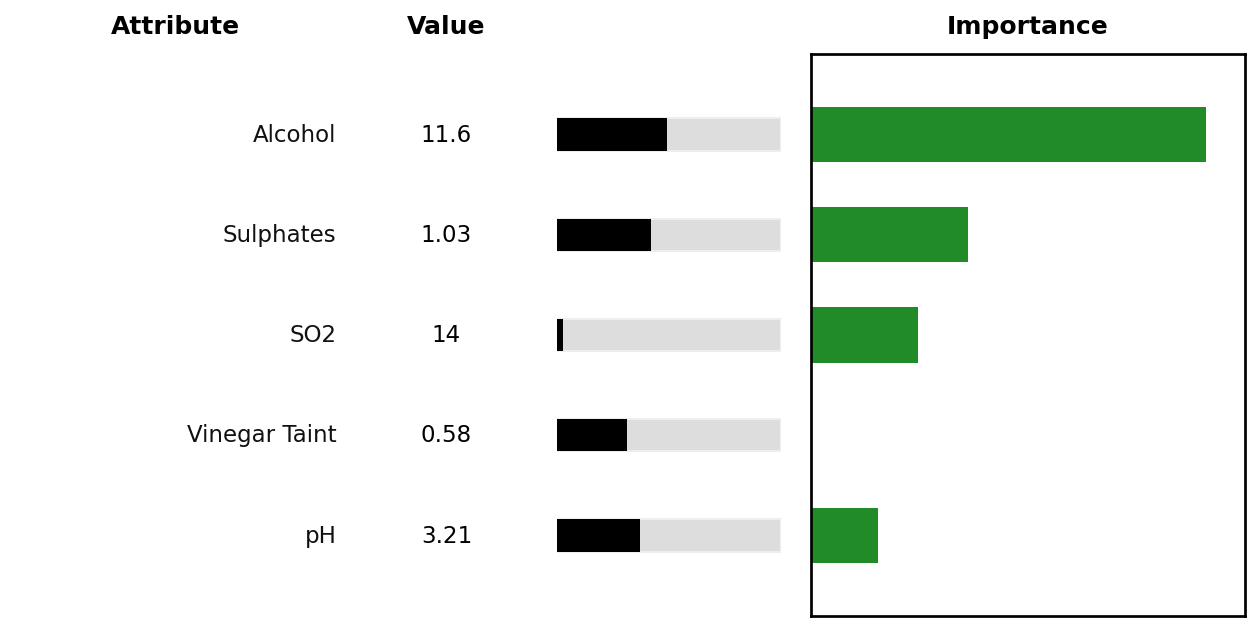
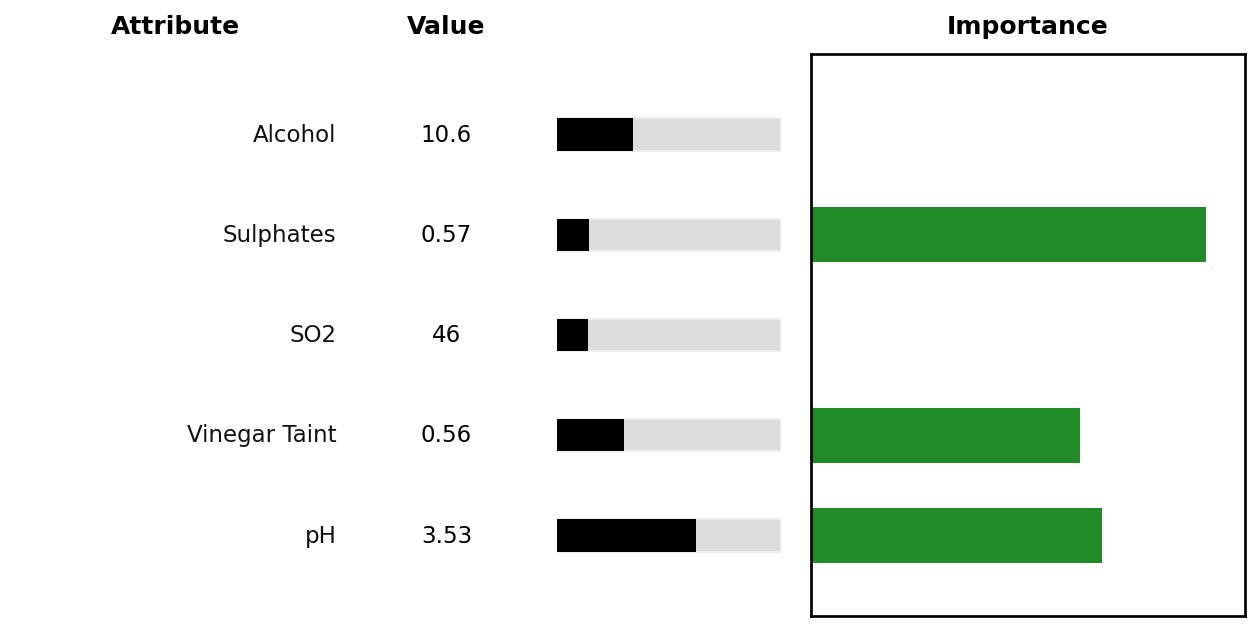
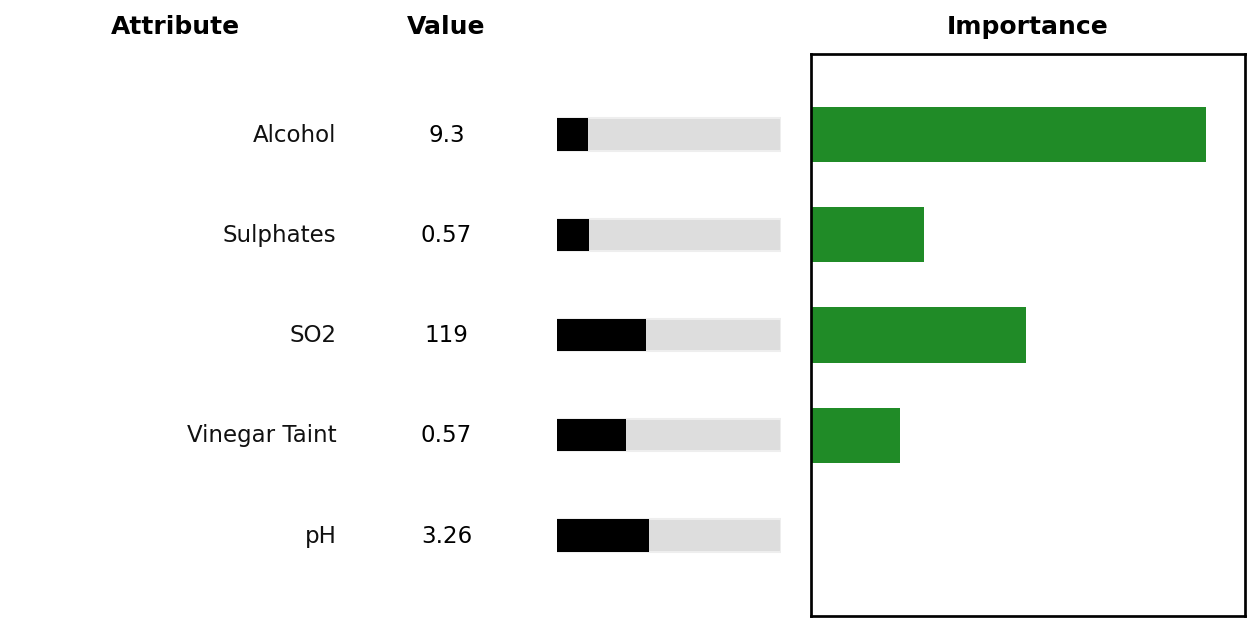
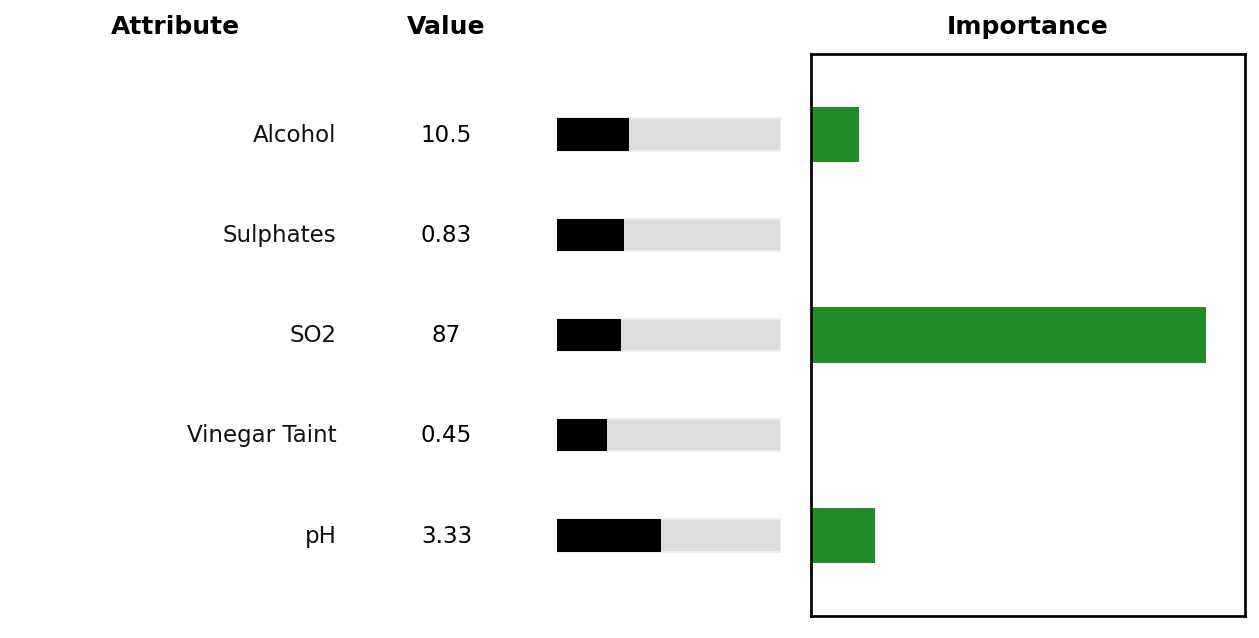
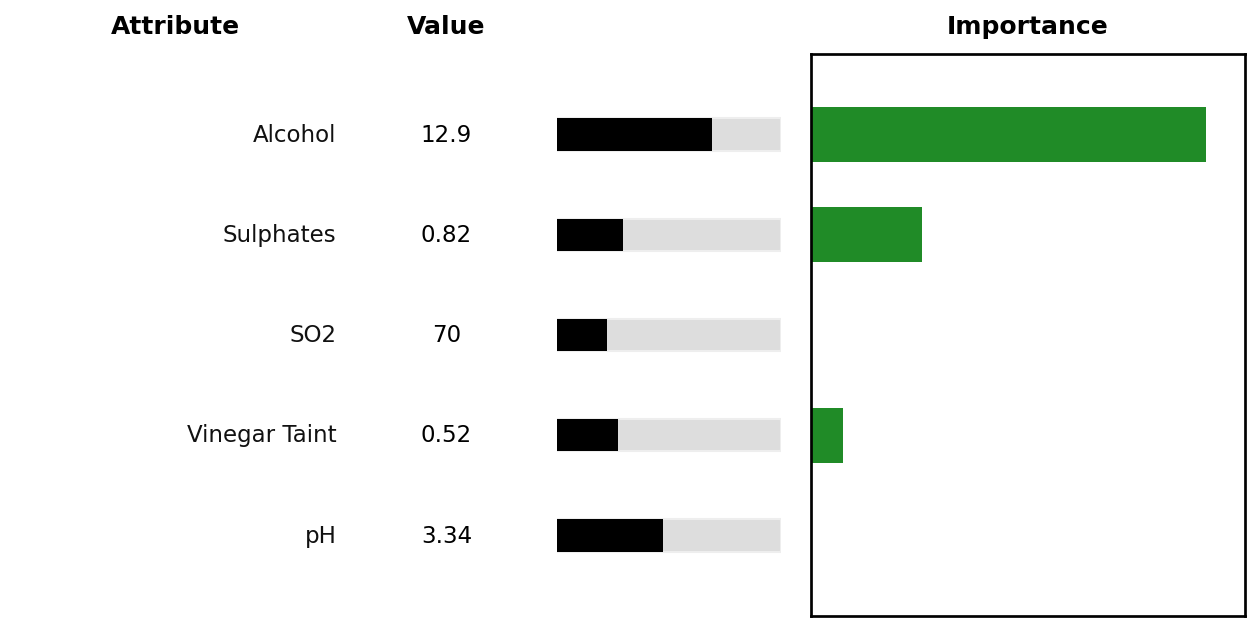
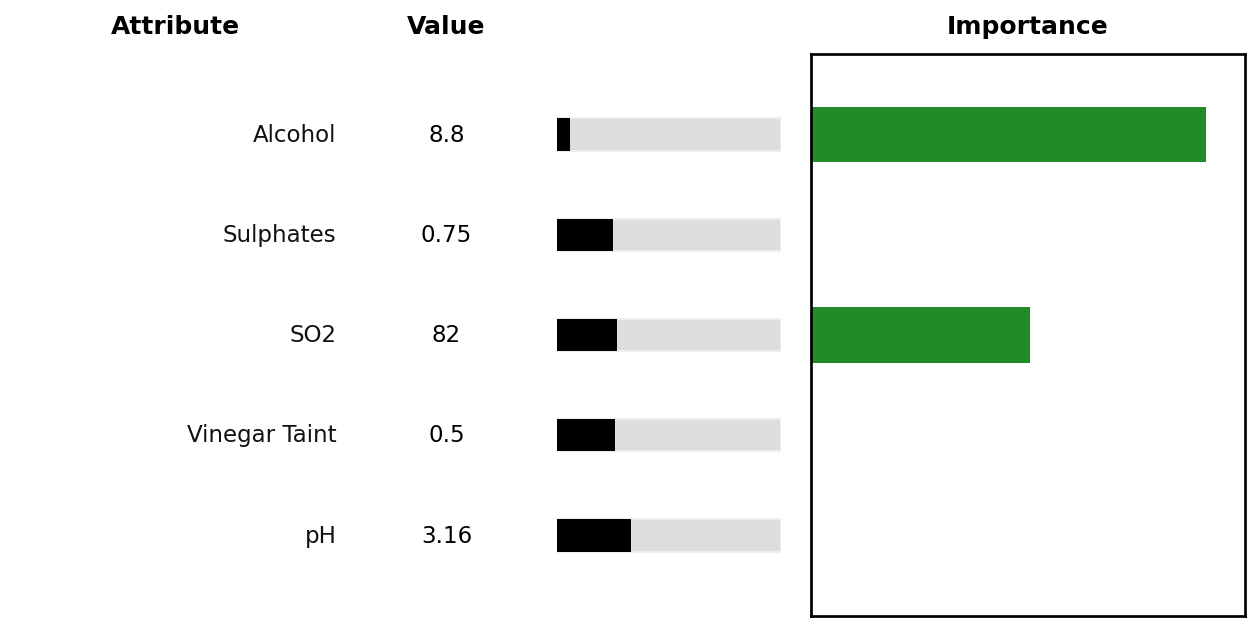
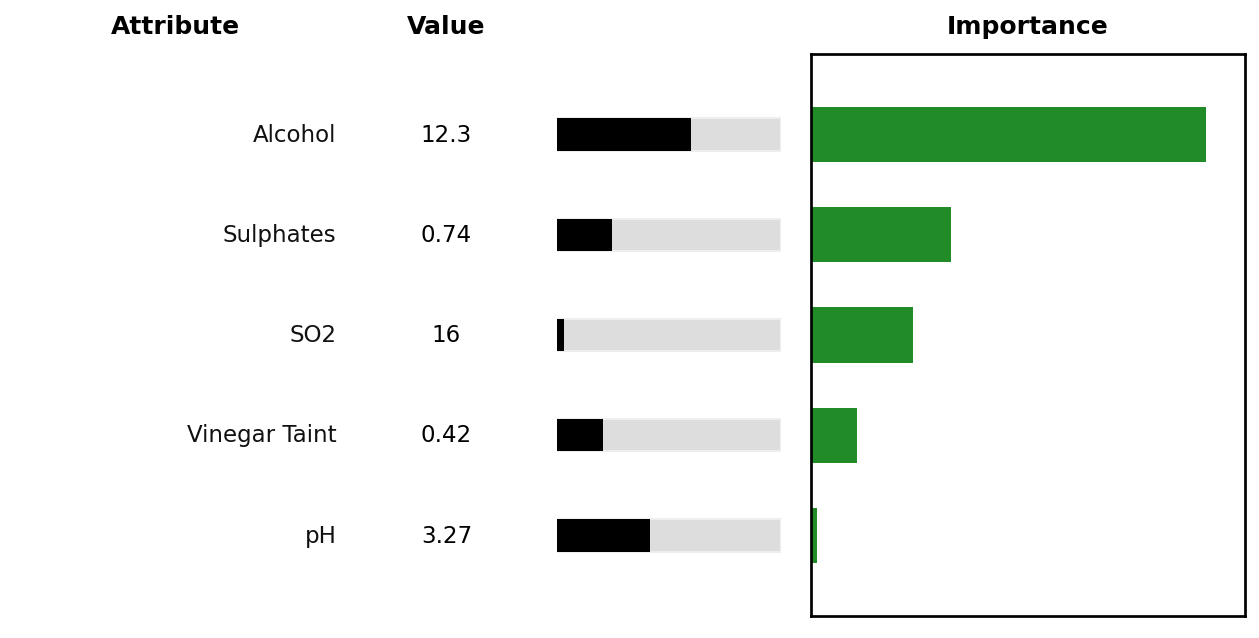

In [5]:
study.set_cognitive_model(
    cognitive_model_id=BASELINE_MODEL,
    model_kwargs={'n_neighbors': 3} if BASELINE_MODEL == 'knn' else {},
)
preview_id = int(trials.loc[trials['xai_type'].eq('attribution'), 'participantId'].iloc[0])
participant_trials = study.preview_participant_trials(
    participant_id=preview_id,
    visualization='importance',
    class_labels=['Type 1', 'Type 2'],
    fallback='html',
)

## 5. Run and analyze the virtual experiment

,index,xai_type,count,mean,std,sem
0,0,attribution,8,0.64375,0.176144,0.062276
1,1,importance,8,0.63125,0.122292,0.043237
2,2,none,8,0.63125,0.099777,0.035276


Saved 720 responses to /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_output/simulated_results/simulated_results.csv and /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/feature_explanation_output/simulated_results/simulated_results.json


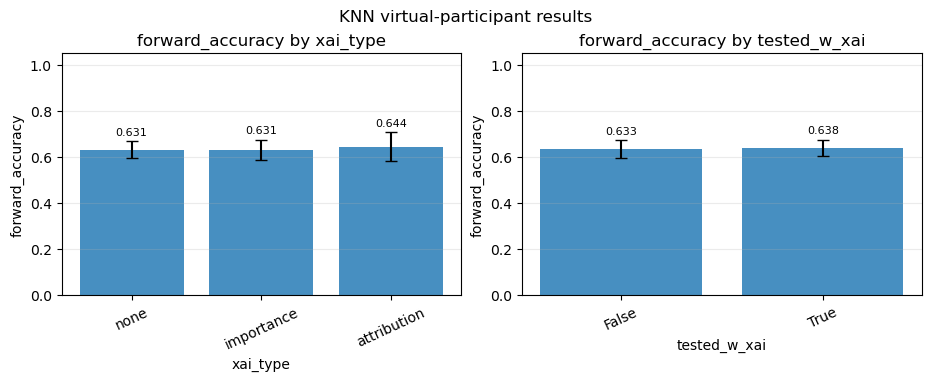

In [6]:
simulated_results = study.run_experiment(
    mode='whole_experiment',
    participant_id=None,
    explanation_pool=prediction_pool,
)
csv_path, json_path = study.save_results(out_dir='simulated_results')
analysis = study.analyze_iv_dv(iv='xai_type', dv='forward_accuracy')
display(analysis.descriptives)
study.plot_results_grid(
    ivs=['xai_type', 'tested_w_xai'],
    dvs=['forward_accuracy'],
    phase='testing',
    title='KNN virtual-participant results',
)
print(f'Saved {len(simulated_results):,} responses to {csv_path} and {json_path}')

## Before a human study

Treat the KNN output as a machine-proxy check, not evidence about people. Freeze stimuli and analysis rules, justify the human sample size, and obtain ethics approval where required.